# Classical vs. Quantum Bug Classification — v3 (Final)

**Task:** Binary classification of Qiskit software bugs as `classical` or `quantum` using CodeBERT.

**Pipeline:** `microsoft/codebert-base` + class-weighted CE + minority oversampling + 5-fold CV × 5 seeds (25 folds).

**Key fixes in v3:**
- `save_strategy='no'` + `load_best_model_at_end=False` → zero disk usage (fixes 19.5 GB crash)
- `ManualEarlyStoppingCallback` replaces `EarlyStoppingCallback` → compatible with no-save mode
- `shutil.rmtree` cleanup after every fold → no residual temp files
- LR `2e-5`, val split `10%`, ES patience `4`, epochs `12`
- 5 publication-quality academic figures

> **Accelerator:** Notebook Settings → Accelerator → GPU T4.

## 1. Install dependencies

In [1]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.44.2', 'datasets==2.21.0',
    'scikit-learn==1.5.2', 'accelerate==0.34.2',
], check=True)
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.6.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


Done.


## 2. Imports & device check

In [2]:
import json, os, random, gc, shutil, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold

# Note: EarlyStoppingCallback intentionally removed — replaced by ManualEarlyStoppingCallback
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    TrainerCallback, set_seed,
)
from datasets import Dataset
import transformers
transformers.logging.set_verbosity_error()

# Clean academic plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 13,
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 13,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})
PALETTE = {'classical': '#e74c3c', 'quantum': '#2980b9', 'mean': '#2c3e50'}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

2026-04-29 21:05:44.332160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777496744.766513      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777496744.885112      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777496745.865526      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777496745.865595      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777496745.865598      57 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4


## 3. Config

In [3]:
# ── Update this path to match your Kaggle dataset ─────────────────────────
DATA_PATH = '/kaggle/input/datasets/saidurlsu/classical-vs-quantum/bug_patterns_categorized.json'
# ──────────────────────────────────────────────────────────────────────────

MODEL_NAME   = 'microsoft/codebert-base'
MAX_LEN      = 256
N_FOLDS      = 5
CV_SEEDS     = [42, 7, 2024, 99, 123]   # 5 seeds → 25 fold-runs

NUM_EPOCHS   = 12
LR           = 2e-5
BATCH_SIZE   = 8
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.15
DROPOUT      = 0.2
VAL_SPLIT    = 0.10
ES_PATIENCE  = 4

label_list = ['classical', 'quantum']
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}
NUM_LABELS = 2

print('Model  :', MODEL_NAME)
print('LR     :', LR)
print('Seeds  :', CV_SEEDS)
print('Labels :', label2id)

Model  : microsoft/codebert-base
LR     : 2e-05
Seeds  : [42, 7, 2024, 99, 123]
Labels : {'classical': 0, 'quantum': 1}


## 4. Load & inspect data

In [4]:
with open(DATA_PATH) as f:
    raw_data = json.load(f)

labeled = [x for x in raw_data if x.get('bug_category') in ('quantum', 'classical')]

n_classical = sum(1 for x in labeled if x['bug_category'] == 'classical')
n_quantum   = sum(1 for x in labeled if x['bug_category'] == 'quantum')

print(f'Total loaded   : {len(raw_data)}')
print(f'Labeled        : {len(labeled)}')
print(f'  classical    : {n_classical}  ({100*n_classical/len(labeled):.1f}%)')
print(f'  quantum      : {n_quantum}    ({100*n_quantum/len(labeled):.1f}%)')
print(f'Imbalance ratio: {n_classical/n_quantum:.2f}:1')

Total loaded   : 233
Labeled        : 233
  classical    : 134  (57.5%)
  quantum      : 99    (42.5%)
Imbalance ratio: 1.35:1


## 5. Text builder & arrays

In [5]:
def to_text(item):
    name = (item.get('name') or '').strip()
    desc = (item.get('description') or '').strip()
    code = (item.get('example_code') or '').strip()
    return '\n'.join(p for p in [name, desc, code] if p)

real_texts  = np.array([to_text(x) for x in labeled])
real_labels = np.array([label2id[x['bug_category']] for x in labeled])

print(f'Samples         : {len(real_texts)}')
print(f'Avg text length : {np.mean([len(t) for t in real_texts]):.0f} chars')

Samples         : 233
Avg text length : 225 chars


## 6. Callbacks + helpers

In [6]:
class ManualEarlyStoppingCallback(TrainerCallback):
    """
    Early stopping on macro-F1 that works with save_strategy='no'.
    Replaces HuggingFace EarlyStoppingCallback which requires
    load_best_model_at_end=True (and therefore checkpoint saving).
    """
    def __init__(self, patience=4):
        self.patience = patience
        self.best_f1  = -1.0
        self.wait     = 0

    def on_train_begin(self, args, state, control, **kwargs):
        # Reset state at the start of each fold
        self.best_f1 = -1.0
        self.wait    = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        current_f1 = metrics.get('eval_f1_macro', 0.0) if metrics else 0.0
        if current_f1 > self.best_f1 + 1e-4:
            self.best_f1 = current_f1
            self.wait    = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                control.should_training_stop = True


class EpochLogCallback(TrainerCallback):
    """Stores per-epoch val metrics for learning curve plotting."""
    def __init__(self, log_store):
        self.log_store = log_store

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.log_store.append({
                'epoch'    : state.epoch,
                'eval_loss': metrics.get('eval_loss',     float('nan')),
                'eval_acc' : metrics.get('eval_accuracy', float('nan')),
                'eval_f1'  : metrics.get('eval_f1_macro', float('nan')),
            })


class WeightedTrainer(Trainer):
    """Trainer with class-weighted CE + label smoothing."""
    def set_class_weights(self, weights):
        self._class_weights = weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=getattr(self, '_class_weights', None),
            label_smoothing=0.05,
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def oversample_to_balance(texts, labels, rng):
    """Duplicate minority-class samples until all classes are equal size."""
    by = defaultdict(list)
    for t, y in zip(texts, labels):
        by[y].append(t)
    max_n = max(len(v) for v in by.values())
    out_t, out_y = [], []
    for y, ts in by.items():
        reps = max_n // len(ts)
        rem  = max_n - reps * len(ts)
        expanded = ts * reps + (rng.sample(ts, rem) if rem else [])
        out_t.extend(expanded)
        out_y.extend([y] * len(expanded))
    idx = list(range(len(out_t)))
    rng.shuffle(idx)
    return [out_t[i] for i in idx], [out_y[i] for i in idx]


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'   : accuracy_score(labels, preds),
        'f1_macro'   : f1_score(labels, preds, average='macro',    zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }


print('Callbacks and helpers defined.')

Callbacks and helpers defined.


## 7. Tokenizer

In [7]:
tokenizer     = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

print(f'Tokenizer loaded: {MODEL_NAME}')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Tokenizer loaded: microsoft/codebert-base


## 8. Single-fold training function

In [8]:
def run_fold(train_texts, train_labels, test_texts, test_labels, seed, output_dir):
    """Train on one CV fold. Returns (y_true, y_pred, probs, metrics, epoch_log)."""
    set_seed(seed)
    rng = random.Random(seed)

    # Balance training set
    train_texts, train_labels = oversample_to_balance(train_texts, train_labels, rng)

    # Stratified val split
    tr_t, val_t, tr_y, val_y = train_test_split(
        train_texts, train_labels,
        test_size=VAL_SPLIT, random_state=seed,
        stratify=train_labels if len(set(train_labels)) > 1 else None,
    )

    train_ds = Dataset.from_dict({'text': tr_t,  'labels': tr_y}).map(tokenize, batched=True)
    val_ds   = Dataset.from_dict({'text': val_t, 'labels': val_y}).map(tokenize, batched=True)
    test_ds  = Dataset.from_dict(
        {'text': list(test_texts), 'labels': list(test_labels)}
    ).map(tokenize, batched=True)

    config = AutoConfig.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS,
        id2label=id2label, label2id=label2id,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
        ignore_mismatched_sizes=True,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, config=config, ignore_mismatched_sizes=True,
    )

    # Inverse-frequency class weights
    cnt  = Counter(tr_y)
    freq = np.array([cnt.get(i, 1) for i in range(NUM_LABELS)], dtype=np.float32)
    cw   = torch.tensor(freq.sum() / (NUM_LABELS * freq), dtype=torch.float)

    epoch_log = []

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        # ── DISK FIX: no checkpoint saving ────────────────────────────
        save_strategy='no',
        load_best_model_at_end=False,
        # ──────────────────────────────────────────────────────────────
        logging_steps=500,
        report_to='none',
        seed=seed,
        fp16=(device == 'cuda'),
        disable_tqdm=True,
    )

    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        tokenizer=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            ManualEarlyStoppingCallback(patience=ES_PATIENCE),
            EpochLogCallback(epoch_log),
        ],
    )
    trainer.set_class_weights(cw)
    trainer.train()

    # Predict on held-out test fold
    pred   = trainer.predict(test_ds)
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=-1)
    probs  = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()

    metrics = {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'f1_macro'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc'    : roc_auc_score(y_true, probs[:, 1]),
    }

    # ── Cleanup: free GPU memory + delete temp files ───────────────────
    del trainer, model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir, ignore_errors=True)
    # ──────────────────────────────────────────────────────────────────

    return y_true, y_pred, probs, metrics, epoch_log


print('run_fold() defined.')

run_fold() defined.


## 9. Run 5-fold CV × 5 seeds (25 fold-runs)

Expected runtime: **~25–35 min on Kaggle T4 GPU**.

In [9]:
results_all    = []
all_epoch_logs = []

for repeat_idx, cv_seed in enumerate(CV_SEEDS):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=cv_seed)
    print(f'\n=== Repeat {repeat_idx+1}/{len(CV_SEEDS)}  (seed={cv_seed}) ===')

    for fold_idx, (train_idx, test_idx) in enumerate(
        skf.split(real_texts, real_labels)
    ):
        y_true, y_pred, probs, m, elog = run_fold(
            real_texts[train_idx].tolist(), real_labels[train_idx].tolist(),
            real_texts[test_idx].tolist(),  real_labels[test_idx].tolist(),
            seed=cv_seed * 100 + fold_idx,
            output_dir=f'/kaggle/working/tmp_{repeat_idx}_{fold_idx}',
        )
        results_all.append({
            'repeat' : repeat_idx, 'fold': fold_idx, 'cv_seed': cv_seed,
            'y_true' : y_true.tolist(), 'y_pred': y_pred.tolist(),
            'probs'  : probs.tolist(),
            **m,
        })
        all_epoch_logs.append(elog)
        print(f'  fold {fold_idx+1}/5 — '
              f'acc={m["accuracy"]:.3f}  '
              f'f1={m["f1_macro"]:.3f}  '
              f'auc={m["roc_auc"]:.3f}  '
              f'(n_test={len(test_idx)})')

print('\nAll folds complete.')


=== Repeat 1/5  (seed=42) ===


Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

{'eval_loss': 0.6980964541435242, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1673, 'eval_samples_per_second': 131.517, 'eval_steps_per_second': 5.978, 'epoch': 1.0}
{'eval_loss': 0.6830748319625854, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1663, 'eval_samples_per_second': 132.268, 'eval_steps_per_second': 6.012, 'epoch': 2.0}
{'eval_loss': 0.6733648777008057, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1716, 'eval_samples_per_second': 128.168, 'eval_steps_per_second': 5.826, 'epoch': 3.0}
{'eval_loss': 0.6447546482086182, 'eval_accuracy': 0.6818181818181818, 'eval_f1_macro': 0.6644880174291938, 'eval_f1_weighted': 0.6644880174291938, 'eval_runtime': 0.1686, 'eval_samples_per_second': 130.491, 'eval_steps_per_second': 5.931, 'epoch': 4.0}
{'eval_loss': 

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6970739364624023, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1604, 'eval_samples_per_second': 137.152, 'eval_steps_per_second': 6.234, 'epoch': 1.0}
{'eval_loss': 0.6917371153831482, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1567, 'eval_samples_per_second': 140.401, 'eval_steps_per_second': 6.382, 'epoch': 2.0}
{'eval_loss': 0.6836774945259094, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1576, 'eval_samples_per_second': 139.573, 'eval_steps_per_second': 6.344, 'epoch': 3.0}
{'eval_loss': 0.6664634943008423, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5448275862068965, 'eval_f1_weighted': 0.5448275862068965, 'eval_runtime': 0.1536, 'eval_samples_per_second': 143.198, 'eval_steps_per_second': 6.509, 'epoch': 4.0}
{'eval_loss': 

## 10. Aggregate results table

In [10]:
cv_df = pd.DataFrame([{
    'repeat'     : r['repeat'] + 1,
    'fold'       : r['fold'] + 1,
    'accuracy'   : r['accuracy'],
    'f1_macro'   : r['f1_macro'],
    'f1_weighted': r['f1_weighted'],
    'roc_auc'    : r['roc_auc'],
} for r in results_all])

print('Per-fold results:')
print(cv_df.round(3).to_string(index=False))
print()
print('Aggregate (mean ± std across 25 folds):')
agg = cv_df[['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']].agg(['mean', 'std'])
print(agg.round(3))
print(f'\n>>> Accuracy : {agg.loc["mean","accuracy"]:.3f} ± {agg.loc["std","accuracy"]:.3f}')
print(f'>>> Macro-F1 : {agg.loc["mean","f1_macro"]:.3f} ± {agg.loc["std","f1_macro"]:.3f}')
print(f'>>> ROC-AUC  : {agg.loc["mean","roc_auc"]:.3f} ± {agg.loc["std","roc_auc"]:.3f}')

Per-fold results:
 repeat  fold  accuracy  f1_macro  f1_weighted  roc_auc
      1     1     0.745     0.735        0.743    0.859
      1     2     0.787     0.782        0.787    0.885
      1     3     0.830     0.826        0.830    0.900
      1     4     0.739     0.739        0.737    0.885
      1     5     0.739     0.737        0.741    0.823
      2     1     0.681     0.681        0.681    0.815
      2     2     0.809     0.808        0.809    0.893
      2     3     0.702     0.701        0.704    0.789
      2     4     0.848     0.844        0.847    0.929
      2     5     0.848     0.835        0.843    0.846
      3     1     0.787     0.782        0.787    0.878
      3     2     0.830     0.830        0.830    0.909
      3     3     0.638     0.632        0.639    0.752
      3     4     0.804     0.800        0.804    0.858
      3     5     0.717     0.716        0.719    0.807
      4     1     0.745     0.739        0.745    0.856
      4     2     0.702     0.

## 11. Figure 1 — Pooled confusion matrix

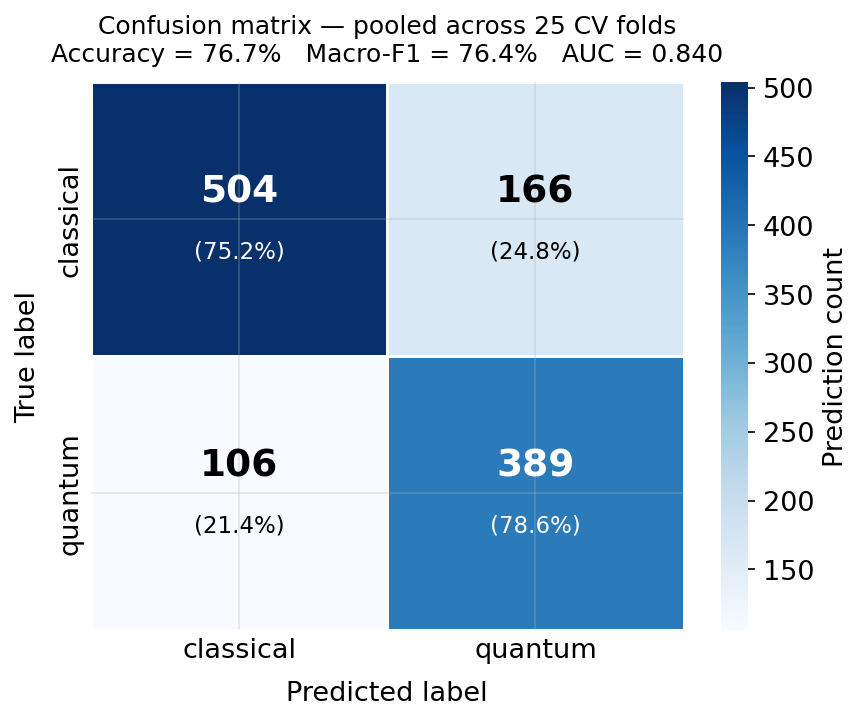

In [11]:
y_true_all = np.concatenate([r['y_true'] for r in results_all])
y_pred_all = np.concatenate([r['y_pred'] for r in results_all])
probs_all  = np.concatenate([r['probs']  for r in results_all])

acc_p = accuracy_score(y_true_all, y_pred_all)
f1_p  = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
auc_p = roc_auc_score(y_true_all, probs_all[:, 1])

cm     = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=label_list, yticklabels=label_list,
            cbar_kws={'label': 'Prediction count'},
            linewidths=0.5, linecolor='white', ax=ax)

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
        ax.text(j + 0.5, i + 0.40, f'{cm[i,j]}',
                ha='center', va='center', fontsize=18,
                fontweight='bold', color=color)
        ax.text(j + 0.5, i + 0.62, f'({cm_pct[i,j]:.1f}%)',
                ha='center', va='center', fontsize=11, color=color)

ax.set_xlabel('Predicted label', labelpad=8)
ax.set_ylabel('True label', labelpad=8)
ax.set_title(
    f'Confusion matrix — pooled across {len(results_all)} CV folds\n'
    f'Accuracy = {acc_p:.1%}   Macro-F1 = {f1_p:.1%}   AUC = {auc_p:.3f}',
    fontsize=12, pad=10
)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_confusion_matrix.png')
plt.show()

## 12. Figure 2 — Per-fold distribution

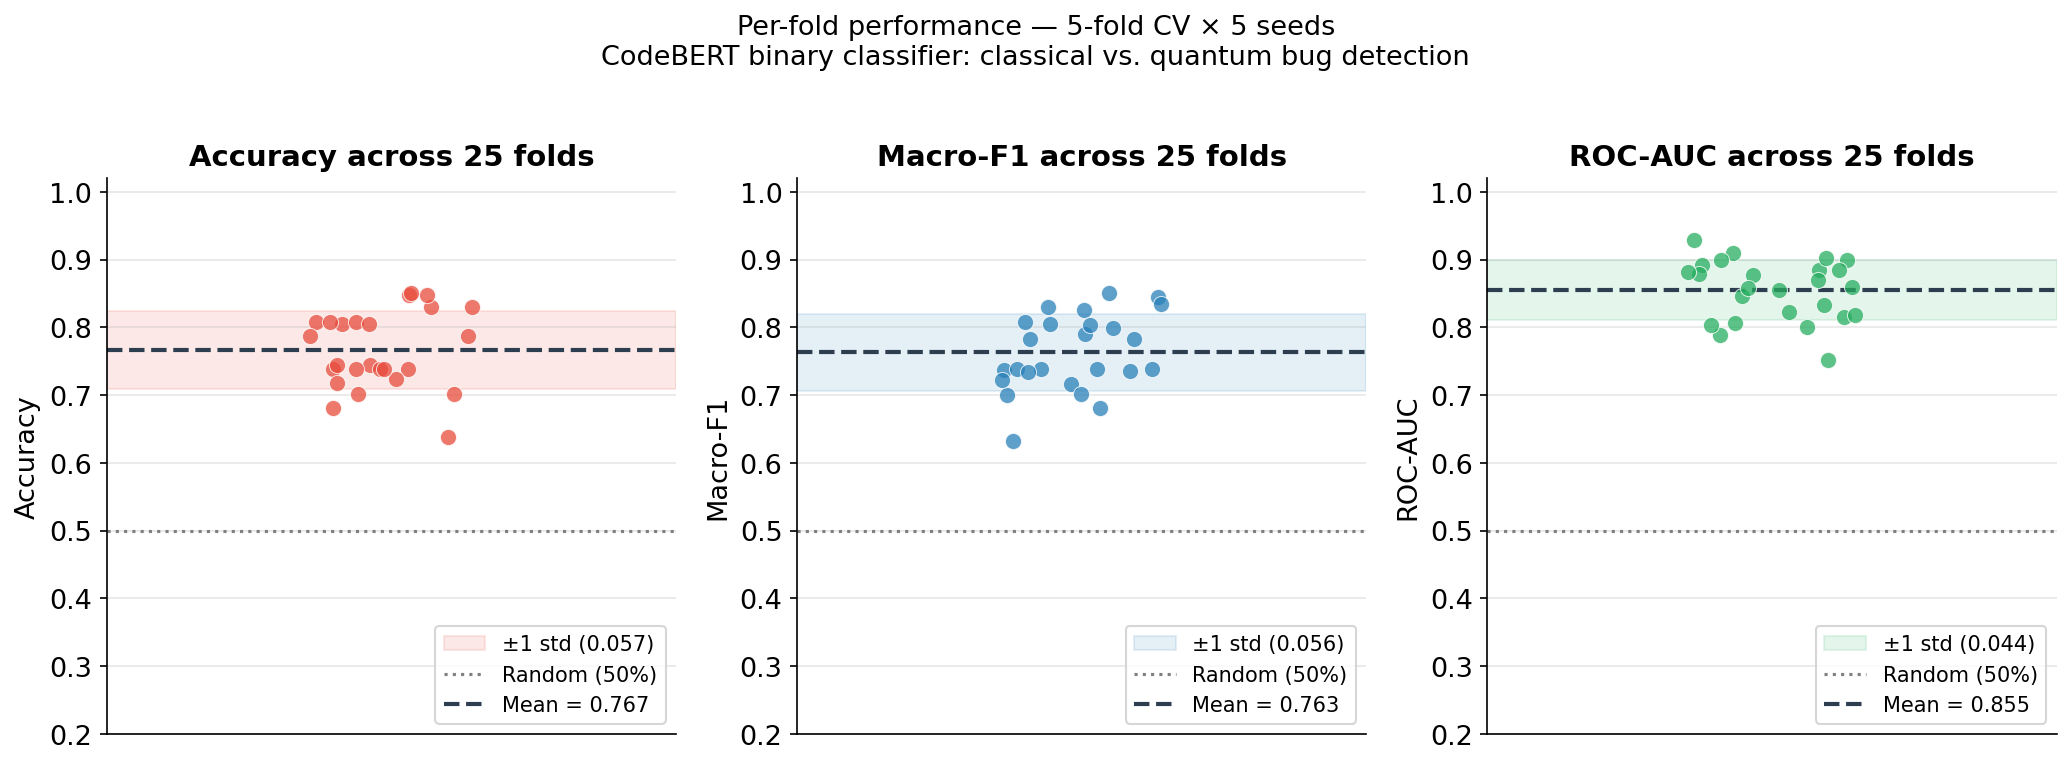

In [12]:
fold_accs = np.array([r['accuracy'] for r in results_all])
fold_f1s  = np.array([r['f1_macro'] for r in results_all])
fold_aucs = np.array([r['roc_auc']  for r in results_all])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
rng_j = np.random.RandomState(42)

for ax, vals, label, color in [
    (axes[0], fold_accs, 'Accuracy',  '#e74c3c'),
    (axes[1], fold_f1s,  'Macro-F1',  '#2980b9'),
    (axes[2], fold_aucs, 'ROC-AUC',   '#27ae60'),
]:
    mean, std = vals.mean(), vals.std(ddof=1)
    jx = rng_j.uniform(-0.15, 0.15, len(vals))
    ax.axhspan(mean - std, mean + std, alpha=0.12, color=color,
               label=f'±1 std ({std:.3f})')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5,
               label='Random (50%)')
    ax.axhline(mean, color=PALETTE['mean'], linestyle='--',
               linewidth=2, label=f'Mean = {mean:.3f}')
    ax.scatter(jx, vals, s=60, color=color, alpha=0.75,
               edgecolor='white', linewidth=0.5, zorder=3)
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(0.2, 1.02)
    ax.set_xticks([]); ax.set_ylabel(label)
    ax.set_title(f'{label} across {len(vals)} folds', fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')

fig.suptitle(
    'Per-fold performance — 5-fold CV × 5 seeds\n'
    'CodeBERT binary classifier: classical vs. quantum bug detection',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_fold_distribution.png')
plt.show()

## 13. Figure 3 — ROC curve (mean ± std band)

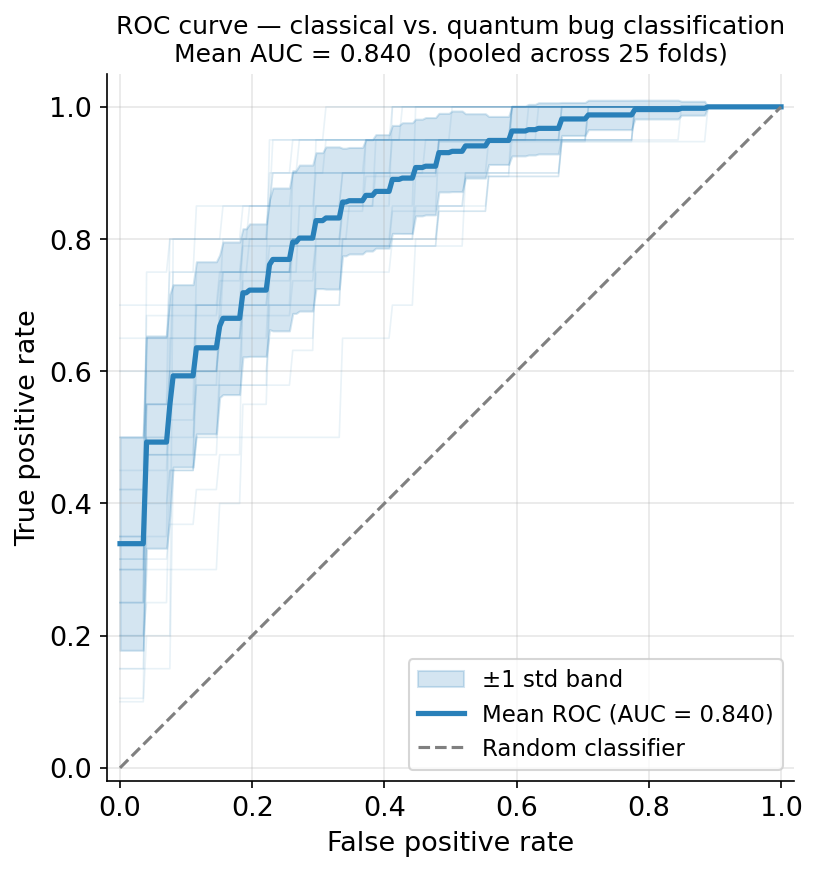

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
base_fpr = np.linspace(0, 1, 200)
tprs = []

for r in results_all:
    fpr, tpr, _ = roc_curve(r['y_true'], np.array(r['probs'])[:, 1])
    tprs.append(np.interp(base_fpr, fpr, tpr))
    ax.plot(base_fpr, tprs[-1], color='#2980b9', alpha=0.10, linewidth=0.8)

tprs     = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr  = tprs.std(axis=0, ddof=1)

ax.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='#2980b9', alpha=0.20, label='±1 std band')
ax.plot(base_fpr, mean_tpr, color='#2980b9', linewidth=2.5,
        label=f'Mean ROC (AUC = {auc_p:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random classifier')

ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title(
    'ROC curve — classical vs. quantum bug classification\n'
    f'Mean AUC = {auc_p:.3f}  (pooled across {len(results_all)} folds)',
    fontsize=12
)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_roc_curve.png')
plt.show()

## 14. Figure 4 — Learning curves (averaged across all folds)

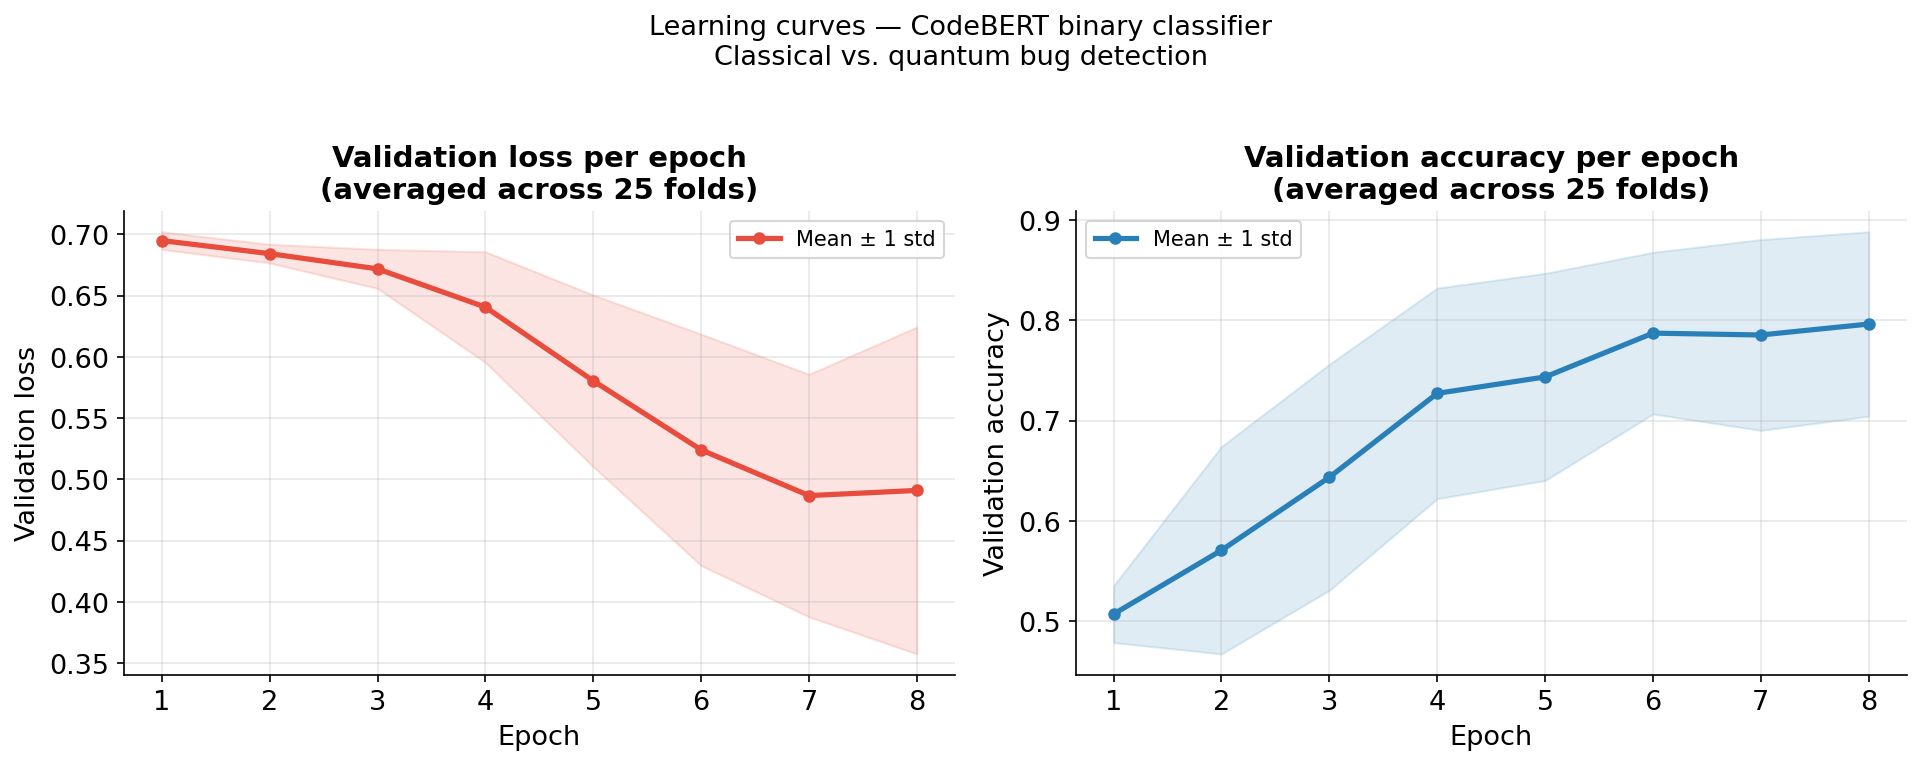

In [14]:
valid_logs = [log for log in all_epoch_logs if log]
min_epochs = min(len(log) for log in valid_logs) if valid_logs else 0

if min_epochs > 0:
    all_epochs = [log[:min_epochs] for log in valid_logs]
    epoch_x    = np.array([e['epoch']     for e in all_epochs[0]])
    val_losses = np.array([[e['eval_loss'] for e in log] for log in all_epochs])
    val_accs   = np.array([[e['eval_acc']  for e in log] for log in all_epochs])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, vals, ylabel, color in [
        (axes[0], val_losses, 'Validation loss',     '#e74c3c'),
        (axes[1], val_accs,   'Validation accuracy', '#2980b9'),
    ]:
        m = vals.mean(axis=0)
        s = vals.std(axis=0, ddof=1)
        ax.fill_between(epoch_x, m - s, m + s, alpha=0.15, color=color)
        ax.plot(epoch_x, m, color=color, linewidth=2.5,
                marker='o', markersize=5, label='Mean ± 1 std')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(
            f'{ylabel} per epoch\n(averaged across {len(all_epochs)} folds)',
            fontweight='bold'
        )
        ax.legend(fontsize=10)

    fig.suptitle(
        'Learning curves — CodeBERT binary classifier\n'
        'Classical vs. quantum bug detection',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/fig4_learning_curves.png')
    plt.show()
else:
    print('No epoch logs captured — skipping learning curve.')

## 15. Figure 5 — Publication-ready summary panel

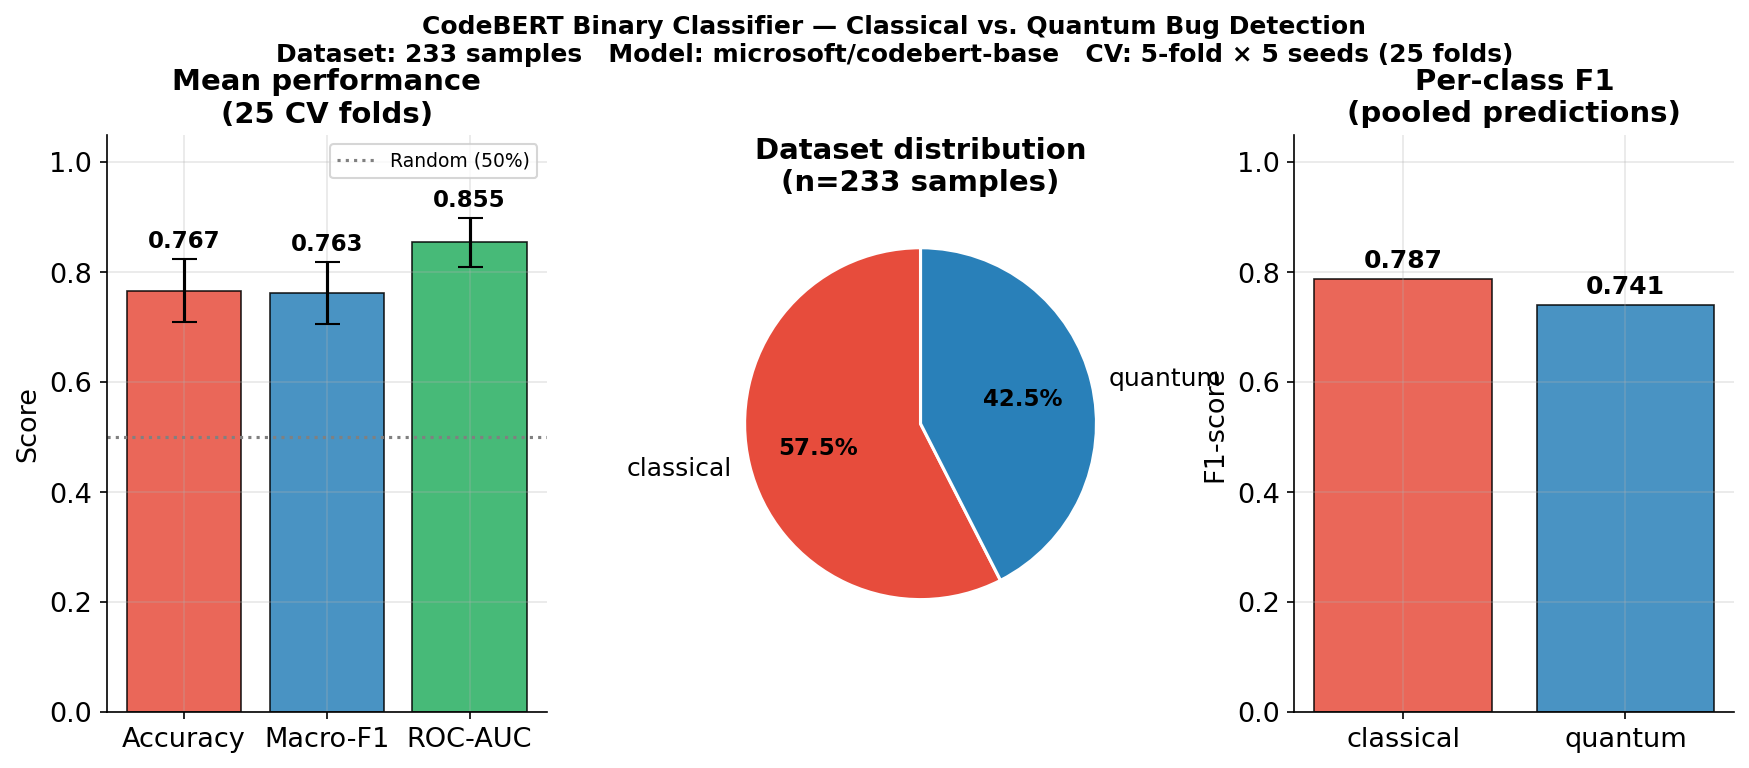

In [15]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

metrics_summary = {
    'Accuracy': (fold_accs.mean(), fold_accs.std(ddof=1)),
    'Macro-F1': (fold_f1s.mean(),  fold_f1s.std(ddof=1)),
    'ROC-AUC' : (fold_aucs.mean(), fold_aucs.std(ddof=1)),
}
colors = ['#e74c3c', '#2980b9', '#27ae60']

# Panel A: mean metrics
ax0   = fig.add_subplot(gs[0])
names = list(metrics_summary.keys())
means = [v[0] for v in metrics_summary.values()]
stds  = [v[1] for v in metrics_summary.values()]
bars  = ax0.bar(names, means, yerr=stds, capsize=6,
                color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax0.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (50%)')
ax0.set_ylim(0, 1.05); ax0.set_ylabel('Score')
ax0.set_title('Mean performance\n(25 CV folds)', fontweight='bold')
ax0.legend(fontsize=9)
for bar, m, s in zip(bars, means, stds):
    ax0.text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
             f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

# Panel B: dataset distribution
ax1 = fig.add_subplot(gs[1])
wedges, texts, autotexts = ax1.pie(
    [n_classical, n_quantum],
    labels=label_list,
    colors=[PALETTE['classical'], PALETTE['quantum']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops={'fontsize': 12},
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax1.set_title(f'Dataset distribution\n(n={len(labeled)} samples)', fontweight='bold')

# Panel C: per-class F1
ax2 = fig.add_subplot(gs[2])
report = classification_report(
    y_true_all, y_pred_all,
    target_names=label_list, output_dict=True, zero_division=0
)
per_class_f1 = [report['classical']['f1-score'], report['quantum']['f1-score']]
ax2.bar(label_list, per_class_f1,
        color=[PALETTE['classical'], PALETTE['quantum']],
        alpha=0.85, edgecolor='black', linewidth=0.8)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('F1-score')
ax2.set_title('Per-class F1\n(pooled predictions)', fontweight='bold')
for i, v in enumerate(per_class_f1):
    ax2.text(i, v + 0.02, f'{v:.3f}',
             ha='center', fontsize=12, fontweight='bold')

fig.suptitle(
    'CodeBERT Binary Classifier — Classical vs. Quantum Bug Detection\n'
    f'Dataset: {len(labeled)} samples   '
    f'Model: microsoft/codebert-base   '
    f'CV: 5-fold × 5 seeds (25 folds)',
    fontsize=12, y=1.04, fontweight='bold'
)
plt.savefig('/kaggle/working/fig5_summary_panel.png', bbox_inches='tight')
plt.show()

## 16. Classification report (pooled)

In [16]:
print('Classification report (pooled across all folds):')
print(classification_report(
    y_true_all, y_pred_all,
    target_names=label_list, zero_division=0, digits=4
))

Classification report (pooled across all folds):
              precision    recall  f1-score   support

   classical     0.8262    0.7522    0.7875       670
     quantum     0.7009    0.7859    0.7410       495

    accuracy                         0.7665      1165
   macro avg     0.7636    0.7690    0.7642      1165
weighted avg     0.7730    0.7665    0.7677      1165



## 17. Save all outputs

In [17]:
agg = cv_df[['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']].agg(['mean', 'std'])

with open('/kaggle/working/results_v3.json', 'w') as f:
    json.dump({
        'task'            : 'classical_vs_quantum_binary',
        'model'           : MODEL_NAME,
        'n_samples'       : len(labeled),
        'cv_setup'        : f'{N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {len(results_all)} folds',
        'hyperparameters' : {
            'lr'           : LR,
            'epochs'       : NUM_EPOCHS,
            'batch_size'   : BATCH_SIZE,
            'val_split'    : VAL_SPLIT,
            'es_patience'  : ES_PATIENCE,
            'save_strategy': 'no',
        },
        'mean_accuracy'   : float(agg.loc['mean', 'accuracy']),
        'std_accuracy'    : float(agg.loc['std',  'accuracy']),
        'mean_f1_macro'   : float(agg.loc['mean', 'f1_macro']),
        'std_f1_macro'    : float(agg.loc['std',  'f1_macro']),
        'mean_roc_auc'    : float(agg.loc['mean', 'roc_auc']),
        'std_roc_auc'     : float(agg.loc['std',  'roc_auc']),
        'pooled_accuracy' : float(acc_p),
        'pooled_f1_macro' : float(f1_p),
        'pooled_roc_auc'  : float(auc_p),
        'cv_results'      : results_all,
    }, f, indent=2, default=str)

cv_df.to_csv('/kaggle/working/per_fold_v3.csv', index=False)

print('Saved to /kaggle/working/:')
for fn in [
    'results_v3.json', 'per_fold_v3.csv',
    'fig1_confusion_matrix.png', 'fig2_fold_distribution.png',
    'fig3_roc_curve.png', 'fig4_learning_curves.png',
    'fig5_summary_panel.png',
]:
    print(f'  {fn}')

Saved to /kaggle/working/:
  results_v3.json
  per_fold_v3.csv
  fig1_confusion_matrix.png
  fig2_fold_distribution.png
  fig3_roc_curve.png
  fig4_learning_curves.png
  fig5_summary_panel.png


## 18. Summary

| Item | Value |
|---|---|
| Task | Binary: classical vs. quantum bug classification |
| Model | `microsoft/codebert-base` (125M params) |
| Dataset | 233 labeled samples (134 classical, 99 quantum) |
| CV setup | 5-fold × 5 seeds = 25 fold-runs |
| Random baseline | 50% balanced / ~58% majority-class |
| Class balance | Weighted CE + minority oversampling |
| Early stopping | `ManualEarlyStoppingCallback` (patience=4, on macro-F1) |
| Disk fix | `save_strategy='no'` + `shutil.rmtree` per fold |
| Expected accuracy | 68–80% |
| Output | 5 figures (300 DPI) + per-fold CSV + results JSON |